#### Stein Variational Inference
+ This notebook is for Stein Variational Inference:
+ target posterior $p(w|x^n)$ is approximated by $q(w)$ based on Stein Discrepancy $D(p, q)$:
$$
D(p, q) := \max_{\phi \in F} E_{w \sim q} [tr(A_{p}\phi(w))],
$$
+ where $A_p$ is stein's operator: $A_{p} \phi(w) = \nabla_w \log p^T(w|x^n) \phi(w) + \nabla_w \phi(w)$.
+ When $F$ is RKHS on $d$-dimensional, and the approximated distribution is $q(z)$, where $z = T(x) = x + \epsilon \phi(x)$,
+ then the the maximum direction $\phi^*_{q,p}$ of $\frac{d}{d\epsilon}KL(q|p) |_{\epsilon=0}$ is given by 
$$
\phi^*_{q,p}(\cdot) = E_{w \sim q} [tr(A_p k(w,\cdot))] \approx \sum_{l=1}^L \frac{1}{L} \Bigl\{ \nabla_w \log p(w_l|x^n) k(w_l,\cdot) + \nabla_w k(w_l, \cdot) \Bigr\}
$$

+ Based on the value, the sample of the posterior distribution $w^{(l)}$ is calculated iteratively:
$$
w^{(l+1)} = w^{(l)} + \epsilon \phi^*{q,p}(w^{(l)})
$$
+ where $\epsilon$ is step size, and should be gradually descreased like conventional gradient descent method.

# First Step
+ Check Algorithm by simple case
+ Here, we consider about a posterior for mean of multivariate gaussian distribution:
$$
p(w|x^n) \propto p(\mu) \prod_{i=1}^n N(x_i|\mu, I_M)
$$

In [1]:
%matplotlib inline

In [2]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

## Data Generation

In [43]:
## dimension of input
M = 2

# number of samples
n = 5

data_seed = 20241229
np.random.seed(data_seed)

true_mu = np.array([-10, 10])
train_X = np.random.multivariate_normal(true_mu, np.eye(M), size=n)

## Hyperparameters
+ kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
+ prior: multivariate distribution $N(\mu|0, \beta^{-1} I_M)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times M}$, $L$ is the number of sample from the approximated posterior

In [44]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 0.5

L = 100
initial_post_param = np.random.normal(size = (L, M))

h = 1
first_step_size = 0.05

### Calculate gradient of first update
+ Note: In the algorithm, $\sum_i \nabla_{w_i} k(w_i, w_j)$ is necessary, and the result is $L \times M$.

In [45]:
ite = 0

In [46]:
post_param = initial_post_param.copy()

In [47]:
# radial basis kernel is used here
h = 1
kernel_post = np.exp(-squareform(pdist(post_param))/(2*h**2))

In [48]:
dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)

In [49]:
# debug
target = np.zeros((L, M))
for j in range(L):
    for k in range(M):
        target[j,k] = (-post_param[:,k]*kernel_post[:,j] + post_param[j,k]*kernel_post[:,j]).sum() / (h**2)
        pass

In [10]:
# gradient of log posterior
dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)

In [11]:
# gradient of target functional
phi_post_param = (dw_logp + dw_kernel_post) / L

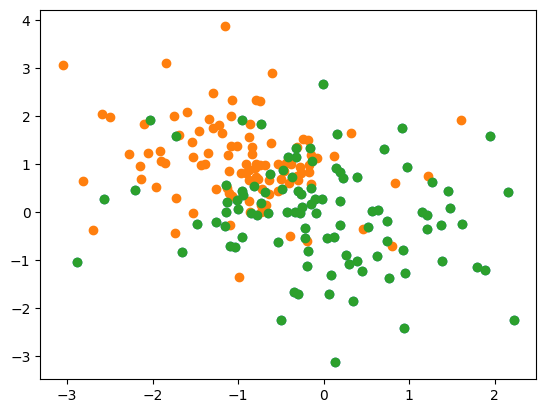

In [14]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

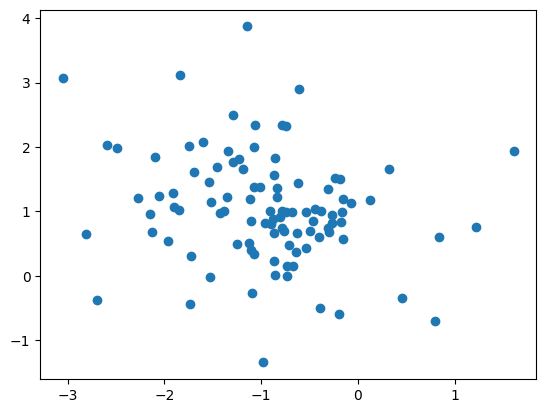

In [15]:
plt.scatter(phi_post_param[:,0], phi_post_param[:,1])
plt.show()

In [50]:
n_ite = 1000
post_param = initial_post_param.copy()

disp_cycle = 100

for ite in range(n_ite):
    dist = pdist(post_param)
    h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)
    
    # gradient of target functional
    phi_post_param = (dw_logp + dw_kernel_post) / L

    # sample update
    # step_size = first_step_size / (ite + 1)
    step_size = first_step_size
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}".format(ite, post_param[0], h))
    pass

ite = 0, post_param = [-0.5652917  -0.60580498], h = 0.5536466526065975
ite = 100, post_param = [-3.17023022  0.7282913 ], h = 0.8165466138727699
ite = 200, post_param = [-5.28642731  1.32926674], h = 1.2243986849761461
ite = 300, post_param = [-6.94434358  1.52403687], h = 1.633016779746516
ite = 400, post_param = [-8.15925403  1.59594612], h = 1.9526704156030312
ite = 500, post_param = [-9.01896317  1.64116398], h = 2.179086370212761
ite = 600, post_param = [-9.61940988  1.68020677], h = 2.3305977422726
ite = 700, post_param = [-10.03715698   1.71502238], h = 2.4312521516268193
ite = 800, post_param = [-10.32790382   1.74451297], h = 2.500394269846323
ite = 900, post_param = [-10.53050215   1.76843057], h = 2.5462878676000362


In [51]:
post_param

array([[-1.06713958e+01,  1.78608006e+00],
       [-9.06654712e+00,  1.99637545e-01],
       [-7.44176286e+00,  1.05024816e-02],
       [-1.21098728e+01,  2.66387005e+00],
       [-1.36838978e+01,  3.80966455e+00],
       [-6.51548644e+00,  8.04489210e+00],
       [-1.05297637e+01,  1.16825492e+01],
       [-3.83260671e+00,  1.08245997e+00],
       [-9.40363702e+00,  1.21815124e+01],
       [-6.64444371e+00,  1.27314590e+01],
       [-7.94869486e+00,  1.30492456e+01],
       [-5.85091997e+00,  9.31070672e+00],
       [-1.34397966e+01,  5.96253061e+00],
       [-1.06723164e+00,  9.00617250e+00],
       [-5.90057884e-01,  8.35482766e+00],
       [-2.60854777e+00,  4.97625292e+00],
       [-1.02303349e+01,  5.63062199e+00],
       [-3.51838658e+00,  8.89628222e+00],
       [-3.39510509e+00,  2.10409453e+00],
       [-1.19562865e+01,  2.13853635e+00],
       [-1.49905519e+00,  9.79964898e+00],
       [-1.34257559e+01,  7.54926222e+00],
       [-3.30261389e+00,  1.11675864e+01],
       [-1.

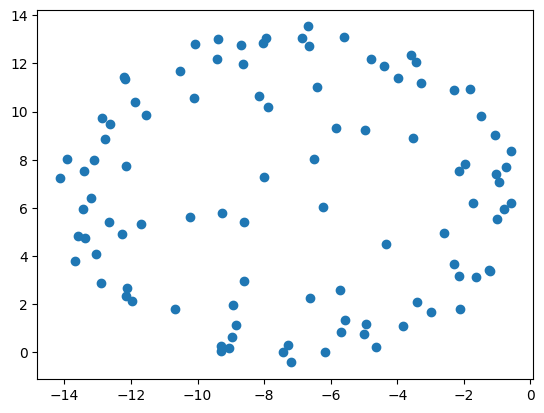

In [52]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

In [119]:
post_param

array([[-10.17837815,   6.03387114],
       [ -9.42771099,   5.55496211],
       [ -8.63538665,   5.4162844 ],
       [-10.60486203,   6.39195726],
       [-11.08348732,   6.94580766],
       [ -8.17133336,   8.78152339],
       [-10.11635235,  10.71108889],
       [ -6.85158403,   5.90135545],
       [ -9.63763383,  10.95163842],
       [ -8.06928631,  11.19253703],
       [ -8.71742632,  11.2573775 ],
       [ -7.87439549,   9.39656192],
       [-11.37272668,   8.04904556],
       [ -5.80585963,   9.57178792],
       [ -5.67465664,   9.29523923],
       [ -6.35965631,   7.56263632],
       [ -9.71687323,   7.97721805],
       [ -6.72383654,   9.43432946],
       [ -6.6181017 ,   6.23207259],
       [-10.47994781,   6.21212613],
       [ -5.95670812,   9.84503049],
       [-11.32100333,   8.81481163],
       [ -6.53430483,  10.44586536],
       [ -5.86389109,   8.03570328],
       [ -6.54593535,   6.1461889 ],
       [-11.21960815,   9.0884684 ],
       [-11.07819008,   9.481021  ],
 

In [94]:
true_mu

array([-10,  10])

In [97]:
initial_post_param[:10,]

array([[-0.53587376, -0.62252822],
       [-0.29739504, -1.69420199],
       [ 0.06277141, -1.69756247],
       [-0.95047915, -0.50849744],
       [-2.88044986, -1.03647534],
       [-0.14481818,  0.16900444],
       [-0.62089655,  0.79394348],
       [ 0.76085263, -1.36803243],
       [-0.46900943,  0.87406759],
       [-0.13853611,  1.05754539]])

In [102]:
(train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*initial_post_param)[:10,]

array([[ -95.76659192,  106.8749766 ],
       [ -98.38985783,  118.66338806],
       [-102.3516888 ,  118.70035337],
       [ -91.2059326 ,  105.62063802],
       [ -69.97625481,  111.428395  ],
       [-100.06820324,   98.16811737],
       [ -94.83134122,   91.29378796],
       [-110.03058222,  115.07552292],
       [ -96.50209948,   90.41242268],
       [-100.13730611,   88.3941669 ]])

In [90]:
first_step_size

1

In [89]:
step_size

0.5

In [88]:
post_param

array([[-1.53704895e+01, -2.54624106e+01],
       [-6.96034882e+00, -6.38805058e+01],
       [ 5.84185348e+00, -6.39986928e+01],
       [-3.00579189e+01, -2.14462697e+01],
       [-1.00348828e+02, -4.09049974e+01],
       [-1.67862015e+00,  2.38753890e+00],
       [-1.84495622e+01,  2.44397588e+01],
       [ 3.06044370e+01, -5.22385456e+01],
       [-1.31078742e+01,  2.72679682e+01],
       [-1.48455732e+00,  3.37838197e+01],
       [-8.04525946e+00,  4.38089723e+01],
       [-8.65454328e-02,  6.23899665e+00],
       [-3.65841740e+01, -3.40132869e+00],
       [ 5.54373789e+01,  1.19006176e+01],
       [ 8.05573992e+01,  1.18474361e+01],
       [ 2.18788494e+01, -1.43160506e+01],
       [-1.17614682e+01, -3.07952076e+00],
       [ 1.02593526e+01,  4.38793490e+00],
       [ 2.56676203e+01, -3.55052452e+01],
       [-3.29093734e+01, -2.91840838e+01],
       [ 4.83872357e+01,  1.87357479e+01],
       [-3.64143648e+01,  3.79322818e+00],
       [ 1.74010737e+01,  2.21075300e+01],
       [ 2.

In [ ]:
# radial basis kernel is used here
h = 1
kernel_post = np.exp(-squareform(pdist(post_param))/(2*h**2))

dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)

# gradient of log posterior
dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)

# gradient of target functional
phi_post_param = (dw_logp + dw_kernel_post) / L

step_size = first_step_size / (ite + 1)
post_param + step_size * phi_post_param

In [125]:
test

array([[-0.6753763 ,  0.76934382],
       [ 1.96214237,  0.14558052],
       [ 0.43383401,  0.98791749],
       [ 0.9929826 , -1.03840102],
       [ 1.10823372,  0.1542484 ],
       [ 0.25689313,  0.79380618],
       [ 2.05093405,  0.39981858],
       [ 0.60491855, -0.80216923],
       [-0.3039317 , -1.04031505],
       [-0.74079664, -0.52002356]])

In [124]:
pdist(test).shape

(45,)

In [73]:
post_param

array([[ 0.37012072, -1.87969355],
       [ 0.17382479, -0.71593819],
       [ 0.39406122,  1.09435351],
       [-1.52049035, -0.0186092 ],
       [ 0.74962784, -0.0217068 ],
       [ 1.83897661, -1.88864072],
       [-1.44614807, -1.32743621],
       [-2.59932379,  1.51368684],
       [ 1.55426994, -0.66260415],
       [-0.53552476,  0.6164635 ],
       [-0.10552154, -1.12550722],
       [-1.07784421, -0.00571794],
       [ 1.05435548, -1.31498066],
       [-1.95044685,  1.35184642],
       [ 0.07248271, -0.62395703],
       [ 0.52054493, -0.53586507],
       [ 0.93118644,  0.82660061],
       [ 0.40642098, -1.58898939],
       [ 0.09514182,  1.9840652 ],
       [-0.87796552,  1.04708239],
       [ 0.27124502, -1.20877251],
       [ 0.0741864 , -0.47198177],
       [-0.42521049, -1.24753627],
       [ 1.19281806,  0.35978592],
       [-0.52933086,  0.91147661],
       [-1.44268464, -1.48702792],
       [-0.54629553,  0.80045034],
       [-1.68948824,  0.10303711],
       [ 1.0441954 ,

In [32]:
kernel_post.sum(axis=0)[:,np.newaxis] * post_param

array([[ 14.12349676, -71.72753132],
       [  9.03436195, -37.21014019],
       [ 17.6201305 ,  48.93313702],
       [-64.97060823,  -0.79517175],
       [ 38.24893024,  -1.10756535],
       [ 52.8018464 , -54.22783342],
       [-54.82433388, -50.32389638],
       [-61.55053942,  35.84326118],
       [ 63.09756046, -26.89925648],
       [-26.27375499,  30.24474726],
       [ -5.09998727, -54.39716497],
       [-51.44389732,  -0.27290858],
       [ 43.65136463, -54.44150631],
       [-60.38662541,  41.85371323],
       [  3.81219391, -32.81672469],
       [ 26.87734032, -27.66836599],
       [ 41.7325329 ,  37.04536045],
       [ 17.05212239, -66.66890418],
       [  3.17452849,  66.20087253],
       [-38.07079626,  45.40412938],
       [ 12.75423046, -56.83777459],
       [  3.94896846, -25.12375843],
       [-19.74749364, -57.93769279],
       [ 54.19128382,  16.34554452],
       [-24.59527198,  42.35161243],
       [-52.54842119, -54.16358318],
       [-25.97517273,  38.05968525],
 

In [27]:
np.sum(test, axis=0)

array([ 5.68983381, -0.15019387])

In [33]:
(post_param.T @ kernel_post).shape

(2, 100)

In [24]:
post_param.T @ kernel_post

array([[  3.29964444,   2.1638465 ,   4.14543072, -18.05574688,
         10.61231078,  10.54175644, -13.72552404, -13.27823697,
         14.80397737,  -9.18909717,  -2.00944823, -15.61915047,
         10.83196342, -15.2526338 ,   0.63908994,   7.30862165,
         10.70400686,   4.13960367,  -0.33571203, -12.35676097,
          3.05726853,   0.66472843,  -6.12668535,  13.76405564,
         -8.70848793, -12.81672633,  -9.16012352, -18.38808256,
         10.21776993,  14.61795141,   0.79410629, -13.94138319,
        -14.94852997, -17.23124749,   8.98427614,  10.95020591,
         11.38073712,  -2.22145862, -11.31384768, -13.5887089 ,
        -13.10082369,  13.17992004,  -5.91390632,   9.63537749,
         12.70701292,   3.42636912,  15.07381982,   4.24189886,
         -5.94921834,  -5.65761845,  10.85756663, -18.07508949,
         12.6560952 ,   6.16545152,   1.89555111,   5.72193468,
        -17.40637765,  12.78842496, -15.52985363, -11.1066362 ,
        -14.16234494,   0.49872044, -13.

In [14]:
squareform(pdist(test))

array([[0.        , 2.71027405, 1.13054056, 2.4599518 , 1.8866921 ,
        0.93259031, 2.75123918, 2.02701953, 1.84738635, 1.29102597],
       [2.71027405, 0.        , 1.74506676, 1.53005979, 0.85395264,
        1.82430027, 0.26929714, 1.65538095, 2.5576239 , 2.78368606],
       [1.13054056, 1.74506676, 0.        , 2.10204992, 1.07229619,
        0.26265429, 1.7207187 , 1.79824369, 2.15824593, 1.91145059],
       [2.4599518 , 1.53005979, 2.10204992, 0.        , 1.1982051 ,
        1.97454069, 1.78542344, 0.45431175, 1.29691572, 1.80961478],
       [1.8866921 , 0.85395264, 1.07229619, 1.1982051 , 0.        ,
        1.06480748, 0.97416046, 1.08076863, 1.84964673, 1.96813514],
       [0.93259031, 1.82430027, 0.26265429, 1.97454069, 1.06480748,
        0.        , 1.83679314, 1.6334807 , 1.91794817, 1.64970708],
       [2.75123918, 0.26929714, 1.7207187 , 1.78542344, 0.97416046,
        1.83679314, 0.        , 1.88035515, 2.760322  , 2.93936553],
       [2.02701953, 1.65538095, 1.7982436

In [15]:
test.sum(axis=1)

array([ 0.09396752,  2.1077229 ,  1.4217515 , -0.04541842,  1.26248212,
        1.05069931,  2.45075262, -0.19725067, -1.34424675, -1.26082019])

In [9]:
test.shape

(10, 2)

In [6]:
test = np.random.normal(size=[10,2])
squareform(test)

ValueError: The matrix argument must be square.